# Loan Default Prediction

Predicts the probability that a borrower defaults on a loan, using:

- **Static features**: age, annual income, employment status, credit score, loan amount
- **Dynamic features**: debt-to-income ratio, late payments in the last 12 months, credit utilization, savings rate, average monthly transactions

This notebook generates a realistic **synthetic** dataset (no external download needed), explores it, trains and compares several models, evaluates the best one, and saves a ready-to-use prediction pipeline for the companion Streamlit app (`app.py`).


## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("data")
MODELS_DIR = Path("models")
DATA_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)


## 2. Generate a synthetic loan portfolio

Each borrower's true default probability is built from a weighted combination of risk factors
(low income relative to loan size, poor credit score, high debt-to-income ratio, recent late
payments, high credit utilization, low savings rate, unemployment) passed through a sigmoid, then
an actual default outcome is sampled from that probability. This keeps the relationships realistic
without needing a labeled dataset from outside.

In [ ]:
def generate_loan_data(n=10000, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)

    age = rng.integers(21, 71, size=n)
    annual_income = rng.lognormal(mean=10.8, sigma=0.5, size=n).round(2)          # ~ $30k-$150k typical
    annual_income = np.clip(annual_income, 12000, 400000)

    employment_status = rng.choice(
        ["Employed", "Self-Employed", "Unemployed", "Retired"],
        size=n, p=[0.62, 0.18, 0.08, 0.12]
    )

    credit_score = rng.normal(680, 75, size=n).round().astype(int)
    credit_score = np.clip(credit_score, 300, 850)

    loan_amount = rng.lognormal(mean=9.6, sigma=0.6, size=n).round(2)             # ~ $5k-$60k typical
    loan_amount = np.clip(loan_amount, 1000, 150000)

    debt_to_income_ratio = np.clip(rng.normal(0.35, 0.15, size=n), 0.0, 1.2).round(3)
    late_payments_12m = rng.poisson(lam=0.8, size=n)
    late_payments_12m = np.clip(late_payments_12m, 0, 12)
    credit_utilization = np.clip(rng.normal(0.40, 0.22, size=n), 0.0, 1.0).round(3)
    savings_rate = np.clip(rng.normal(0.10, 0.08, size=n), -0.1, 0.5).round(3)
    avg_monthly_transactions = np.clip(rng.normal(35, 15, size=n), 2, 120).round().astype(int)

    df = pd.DataFrame({
        "age": age,
        "annual_income": annual_income,
        "employment_status": employment_status,
        "credit_score": credit_score,
        "loan_amount": loan_amount,
        "debt_to_income_ratio": debt_to_income_ratio,
        "late_payments_12m": late_payments_12m,
        "credit_utilization": credit_utilization,
        "savings_rate": savings_rate,
        "avg_monthly_transactions": avg_monthly_transactions,
    })

    # --- underlying risk model (used only to label the data, not exposed to the trainer) ---
    loan_to_income = loan_amount / annual_income
    employment_risk = np.select(
        [employment_status == "Unemployed", employment_status == "Self-Employed",
         employment_status == "Retired"],
        [1.4, 0.35, 0.1],
        default=0.0,
    )
    age_risk = np.where((age < 25) | (age > 65), 0.25, 0.0)

    risk_score = (
        -6.0
        + 3.0 * loan_to_income
        - 0.012 * (credit_score - 650)
        + 2.6 * debt_to_income_ratio
        + 0.35 * late_payments_12m
        + 1.8 * credit_utilization
        - 2.2 * savings_rate
        + employment_risk
        + age_risk
        - 0.01 * (avg_monthly_transactions - 35)
    )
    default_prob = 1 / (1 + np.exp(-risk_score))
    df["default"] = rng.binomial(1, default_prob)

    return df

loans = generate_loan_data(n=10000)
loans.to_csv(DATA_DIR / "synthetic_loans.csv", index=False)
print(f"Generated {len(loans):,} rows | default rate: {loans['default'].mean():.2%}")
loans.head()


Generated 10,000 rows | default rate: 8.82%


,age,annual_income,employment_status,credit_score,loan_amount,debt_to_income_ratio,late_payments_12m,credit_utilization,savings_rate,avg_monthly_transactions,default
0,25,28297.75,Employed,719,14687.79,0.311,1,0.546,0.254,52,0
1,59,37396.89,Self-Employed,585,16863.85,0.214,1,0.536,-0.004,14,0
2,53,56162.28,Employed,709,15233.69,0.310,0,0.775,-0.012,11,0
3,42,35804.90,Unemployed,686,7655.02,0.505,2,0.153,0.145,29,0
4,42,42651.46,Employed,578,15465.77,0.476,1,0.159,0.228,50,0


## 3. Exploratory data analysis

In [ ]:
loans.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,10000.0,NaN,NaN,NaN,45.3154,14.35949,21.0,33.0,45.0,58.0,70.0
annual_income,10000.0,NaN,NaN,NaN,55572.886444,30061.070572,12000.0,35073.0075,48526.035,68430.3775,390670.86
employment_status,10000,4,Employed,6128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_score,10000.0,NaN,NaN,NaN,680.2789,74.665056,361.0,630.0,680.5,732.0,850.0
loan_amount,10000.0,NaN,NaN,NaN,17516.558284,11455.720542,1517.24,9838.525,14622.955,21902.1775,150000.0
debt_to_income_ratio,10000.0,NaN,NaN,NaN,0.347812,0.147592,0.0,0.248,0.346,0.446,0.963
late_payments_12m,10000.0,NaN,NaN,NaN,0.7948,0.894971,0.0,0.0,1.0,1.0,6.0
credit_utilization,10000.0,NaN,NaN,NaN,0.401818,0.213767,0.0,0.249,0.397,0.55,1.0
savings_rate,10000.0,NaN,NaN,NaN,0.099185,0.079566,-0.1,0.045,0.099,0.153,0.461
avg_monthly_transactions,10000.0,NaN,NaN,NaN,34.7743,14.936367,2.0,24.0,35.0,45.0,93.0


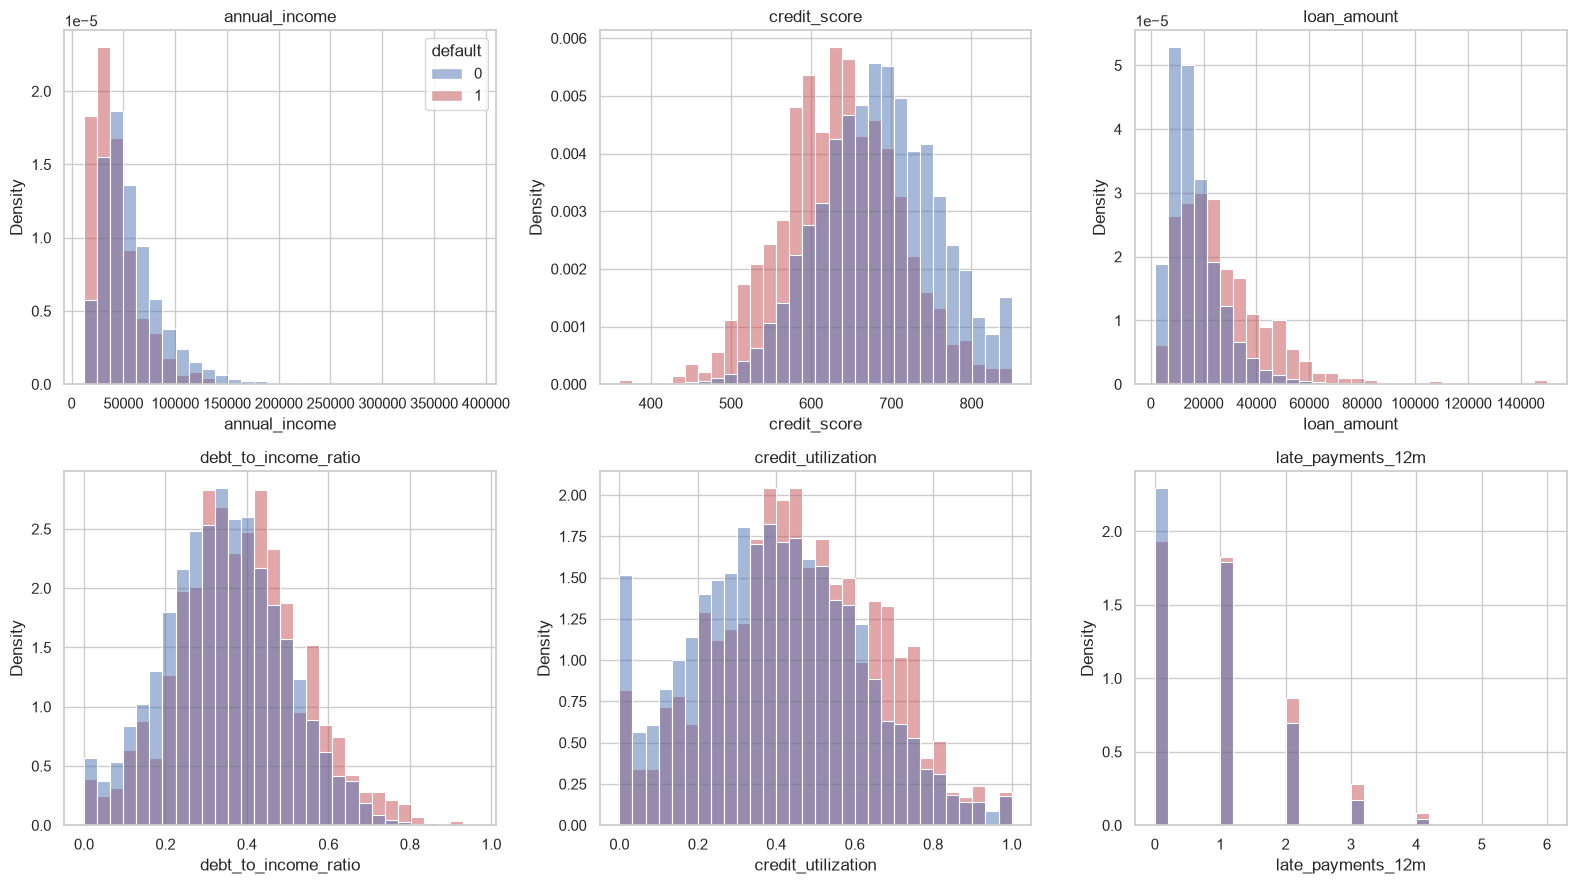

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
num_cols = ["annual_income", "credit_score", "loan_amount",
            "debt_to_income_ratio", "credit_utilization", "late_payments_12m"]
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(data=loans, x=col, hue="default", bins=30, stat="density",
                 common_norm=False, ax=ax, palette=["#4C72B0", "#C44E52"], legend=(col == num_cols[0]))
    ax.set_title(col)
plt.tight_layout()
plt.show()


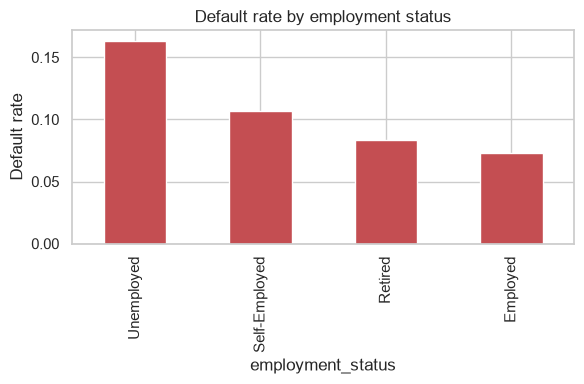

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
default_by_emp = loans.groupby("employment_status")["default"].mean().sort_values(ascending=False)
default_by_emp.plot(kind="bar", ax=ax, color="#C44E52")
ax.set_ylabel("Default rate")
ax.set_title("Default rate by employment status")
plt.tight_layout()
plt.show()


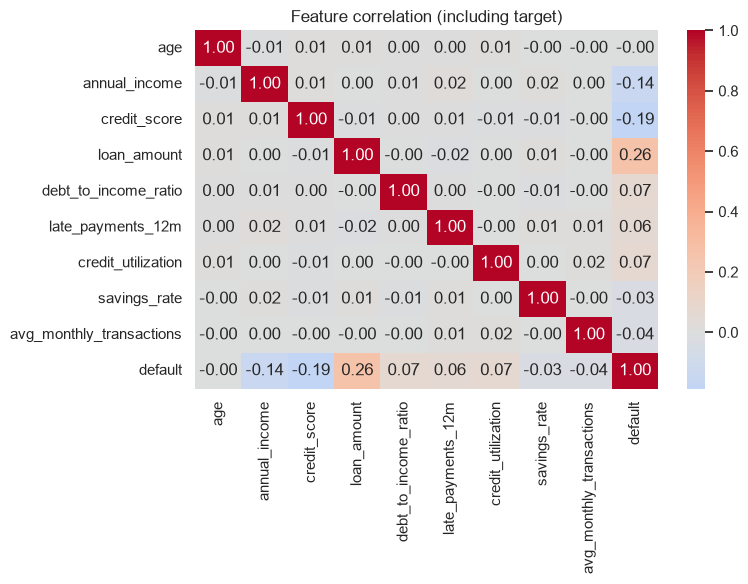

In [ ]:
corr = loans.select_dtypes(include=np.number).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation (including target)")
plt.tight_layout()
plt.show()


## 4. Train / test split and preprocessing

Numeric features are scaled and the categorical `employment_status` is one-hot encoded, all inside
a single `ColumnTransformer` so the exact same steps run at prediction time in the app.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

FEATURE_COLS = [c for c in loans.columns if c != "default"]
NUMERIC_COLS = [c for c in FEATURE_COLS if c != "employment_status"]
CATEGORICAL_COLS = ["employment_status"]

X = loans[FEATURE_COLS]
y = loans["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS),
])

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (8000, 10), Test: (2000, 10)


## 5. Train and compare models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

results = {}
for name, model in candidates.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="roc_auc")
    results[name] = scores
    print(f"{name:22s} ROC-AUC = {scores.mean():.4f} (+/- {scores.std():.4f})")


Logistic Regression    ROC-AUC = 0.8392 (+/- 0.0088)


Random Forest          ROC-AUC = 0.8377 (+/- 0.0073)


Gradient Boosting      ROC-AUC = 0.8456 (+/- 0.0063)


In [ ]:
best_name = max(results, key=lambda k: results[k].mean())
print(f"Best model: {best_name}")

best_pipeline = Pipeline([("prep", preprocessor), ("model", candidates[best_name])])
best_pipeline.fit(X_train, y_train)


Best model: Gradient Boosting


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['age','annual_income','employment_status',...,'credit_utilization', 'savings_rate','avg_monthly_transactions']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

## 6. Evaluate on the held-out test set

In [ ]:
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

y_proba = best_pipeline.predict_proba(X_test)[:, 1]
y_pred = best_pipeline.predict(X_test)

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Average precision (PR-AUC): {average_precision_score(y_test, y_proba):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No default", "Default"]))


ROC-AUC: 0.8156
Average precision (PR-AUC): 0.4302

              precision    recall  f1-score   support

  No default       0.93      0.99      0.96      1824
     Default       0.67      0.23      0.34       176

    accuracy                           0.92      2000
   macro avg       0.80      0.61      0.65      2000
weighted avg       0.91      0.92      0.90      2000



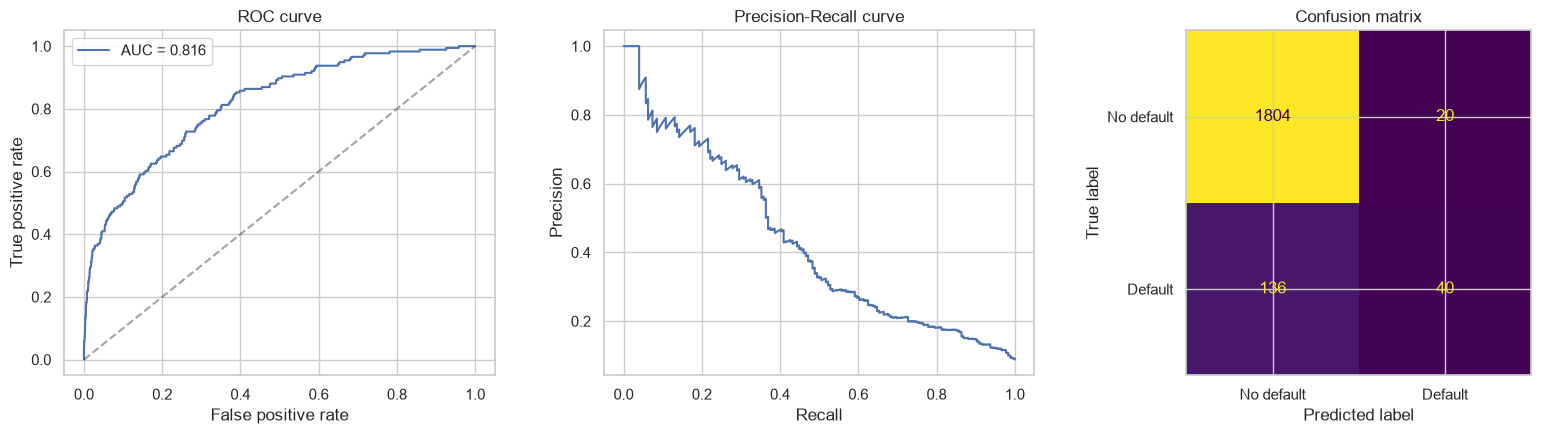

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve"); axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(rec, prec)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No default", "Default"]).plot(ax=axes[2], colorbar=False)
axes[2].set_title("Confusion matrix")

plt.tight_layout()
plt.show()


## 7. Feature importance

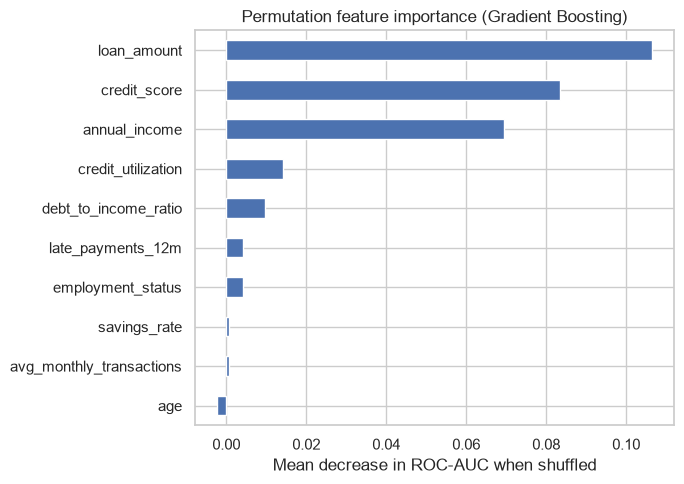

In [ ]:
from sklearn.inspection import permutation_importance

r = permutation_importance(best_pipeline, X_test, y_test, n_repeats=10,
                            random_state=RANDOM_STATE, scoring="roc_auc")

importance = pd.Series(r.importances_mean, index=X_test.columns).sort_values()
plt.figure(figsize=(7, 5))
importance.plot(kind="barh", color="#4C72B0")
plt.xlabel("Mean decrease in ROC-AUC when shuffled")
plt.title(f"Permutation feature importance ({best_name})")
plt.tight_layout()
plt.show()


## 8. Save the pipeline for the app

Saves the full `preprocessor + model` pipeline as one object, so `app.py` can call
`.predict_proba()` directly on a raw one-row DataFrame with the original feature names.

In [ ]:
import joblib

MODEL_PATH = MODELS_DIR / "loan_default_pipeline.joblib"
joblib.dump({
    "pipeline": best_pipeline,
    "feature_cols": FEATURE_COLS,
    "numeric_cols": NUMERIC_COLS,
    "categorical_cols": CATEGORICAL_COLS,
    "model_name": best_name,
    "test_roc_auc": float(roc_auc_score(y_test, y_proba)),
}, MODEL_PATH)

print(f"Saved {best_name} pipeline to {MODEL_PATH}")


Saved Gradient Boosting pipeline to models\loan_default_pipeline.joblib


## Next steps

- Run `streamlit run app.py` from a terminal in this folder to try live predictions.
- Swap in a real dataset by replacing the `generate_loan_data()` call in section 2 with
  `pd.read_csv(...)`, as long as the resulting DataFrame has the same column names.
- Try `xgboost` or `lightgbm` as additional candidates in section 5 for a potential accuracy boost.
